# 10.2 Regression with ARIMA errors using StatsForecast

SARIMAX is fundamentally a linear regression model with exogenous variables, where the residual errors are assumed to follow a SARIMA process instead of being independent white noise.

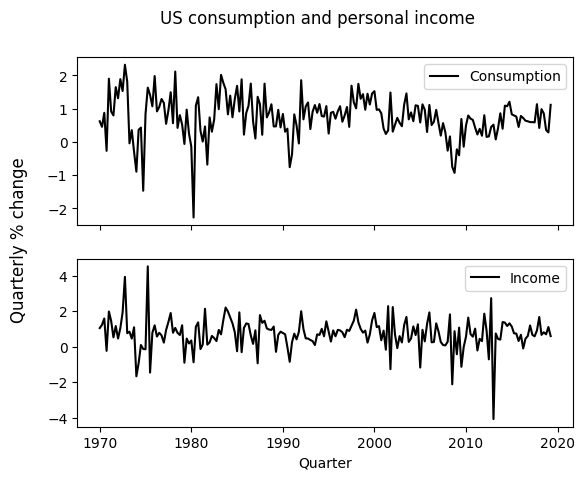

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

us_change = pd.read_csv('../data/fpp3/US_change.csv')
us_change["ds"] = pd.PeriodIndex(
    us_change["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=us_change, x="ds", y="Consumption", color="black",
    label="Consumption", ax=axes[0])
sns.lineplot(data=us_change, x="ds", y="Income", color="black",
    label="Income", ax=axes[1])
axes[0].set(ylabel="")
axes[1].set(ylabel="", xlabel="Quarter")
fig.supylabel("Quarterly % change")
fig.suptitle("US consumption and personal income")
plt.show()

In [7]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.arima import ARIMASummary

df = us_change.assign(unique_id="US")

sf = StatsForecast(models=[AutoARIMA()], freq="QS")
sf = sf.fit(df=df[["unique_id", "ds", "Consumption", "Income"]], target_col="Consumption")

model = sf.fitted_[0, 0].model_
items = list(model["coef"].items())
arma = pd.Series(dict(items[:3]), name="ARMA Coefficients").round(3)
regr = pd.Series(dict(items[3:]), name="Regression Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)
print(ARIMASummary(model), "\n")
print(arma.to_frame(), "\n")
print(regr.to_frame(), "\n")
print(metrics.to_frame())

Regression with ARIMA(1,0,2) errors 

     ARMA Coefficients
ar1              0.707
ma1             -0.617
ma2              0.207 

           Regression Coefficients
intercept                    0.595
ex_1                         0.198 

         Metrics
sigma^2     0.31
loglik   -163.04
aic       338.07
aicc      338.51
bic       357.80


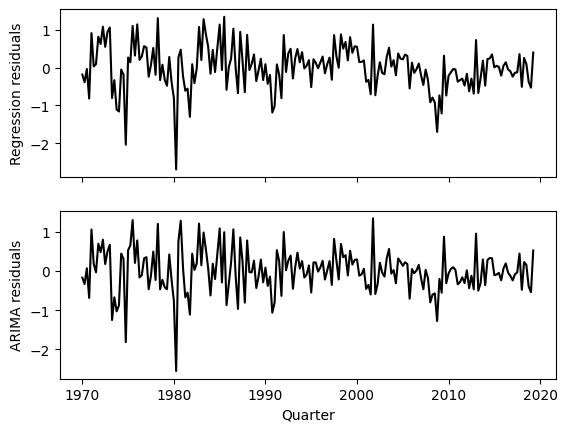

In [8]:
innov_resid = model["residuals"]
reg_resid = (us_change["Consumption"]
    - regr["ex_1"] * us_change["Income"]
    - regr["intercept"])
resid = pd.DataFrame({
    "ARIMA residuals": innov_resid,
    "Regression residuals": reg_resid,
    "ds": us_change["ds"],
})

fig, axes = plt.subplots(2, sharex=True)
sns.lineplot(data=resid, x="ds", y="Regression residuals", color="black",
    ax=axes[0])
sns.lineplot(data=resid, x="ds", y="ARIMA residuals", color="black",
    ax=axes[1])
axes[1].set(xlabel='Quarter')
plt.show()

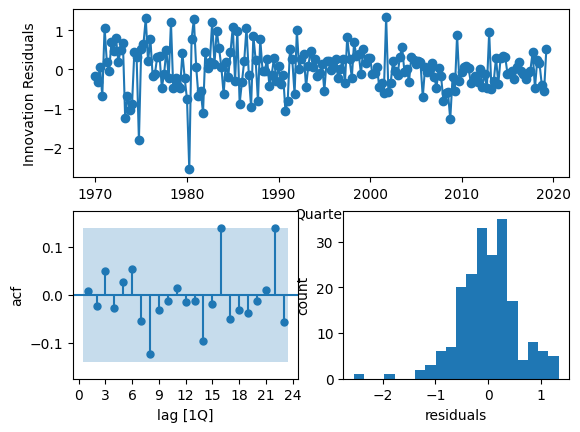

In [12]:
from matplotlib.ticker import MaxNLocator
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(resid["ds"], innov_resid, marker="o")
axes["resid"].set(xlabel="Quarter", ylabel="Innovation Residuals")
plot_acf(innov_resid, ax=axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Q]", ylabel="acf", title="")
axes["hist"].hist(innov_resid, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(innov_resid, lags=[8], model_df=3)
ljung_box

,lb_stat,lb_pvalue
8,5.207175,0.391123
